# Лабораторная работа: Статическая оптимизация и численный поиск экстремалей
 



## Информация  
---
> ФИО_1, ИСУ_1:  
> 
> ФИО_2, ИСУ_2:  
>
> ФИО_3, ИСУ_3:  
---


В данной лабораторной работе рассматривается задача нахождения минимума критерия качества для **статической задачи оптимизации**. Работа охватывает как аналитические (необходимые и достаточные условия), так и численные методы (методы Ньютона — Рафсона и наискорейшего спуска). В качестве приложения рассмотрена задача **численного поиска экстремалей** вариационных задач посредством дискретизации функционала.


В этой работе вы будете использовать следующие библиотеки Python:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.optimize import minimize


In [2]:
# Определение параметров варианта
variant_number = 1  # Измените на свой номер варианта

def get_variant_params(v):
    import numpy as np
    np.random.seed(v)
    params = {
        # Для 1 и 3 части
        'a': np.random.randint(1, 5),
        'b': np.random.randint(1, 5),
        'c': np.random.randint(-10, 10),
        'd': np.random.randint(-10, 10),
        'e': 10,
        'constr_a': np.random.randint(2, 6),
        'R2': np.random.randint(4, 10),
        'p': np.random.randint(1, 4),
        'q': np.random.randint(1, 4),
        # Для 4 части
        'FREQ': np.random.uniform(0.3, 0.8),
        'A_weight': np.random.uniform(0.5, 1.5),
        'B_weight': np.random.uniform(1.0, 3.0),
        'x_start': -4.0, 'y_start': -4.0,
        'x_end': 4.0, 'y_end': 4.0,
        'N_nodes': 30
    }
    return params

params = get_variant_params(variant_number)
print("Ваши параметры:", params)


Ваши параметры: {'a': 2, 'b': 4, 'c': 2, 'd': -2, 'e': 10, 'constr_a': 5, 'R2': 5, 'p': 2, 'q': 1, 'FREQ': 0.3461692973843989, 'A_weight': 0.6862602113776709, 'B_weight': 1.6911214540860955, 'x_start': -4.0, 'y_start': -4.0, 'x_end': 4.0, 'y_end': 4.0, 'N_nodes': 30}


# Часть 1. Поиск глобального минимума на основе необходимого и достаточного условий


## 1.1. Теоретическая справка

Рассмотрим критерий качества (целевую функцию) двух переменных:
$$
J(x, y) = a x^2 + b y^2 + c x + d y + e.
$$

> **Необходимое условие экстремума** (стационарности):
> Точка $(x^*, y^*)$ является стационарной, если градиент целевой функции обращается в нуль:
> $$
> \nabla J(x^*, y^*) = \begin{pmatrix} \frac{\partial J}{\partial x} \\ \frac{\partial J}{\partial y} \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}.
> $$

> **Достаточное условие минимума:**
> Стационарная точка $(x^*, y^*)$ является точкой локального минимума, если матрица Гессе
> $$
> H = \begin{pmatrix} \frac{\partial^2 J}{\partial x^2} & \frac{\partial^2 J}{\partial x \partial y} \\ \frac{\partial^2 J}{\partial y \partial x} & \frac{\partial^2 J}{\partial y^2} \end{pmatrix}
> $$
> является **положительно определённой** в данной точке (все собственные числа положительны, или $\det H > 0$ и $H_{11} > 0$).


## 1.2. Задание: Безусловная оптимизация

**Аналитическая часть.** Для функции $J(x, y) = a x^2 + b y^2 + c x + d y + e.

1. Найдите частные производные $\frac{\partial J}{\partial x}$ и $\frac{\partial J}{\partial y}$.
2. Приравняв их к нулю, найдите стационарную точку $(x^*, y^*)$.
3. Вычислите матрицу Гессе $H$ и проверьте положительную определённость.
4. Найдите $J(x^*, y^*)$.


---
> ❗ **Место для аналитического решения (без ограничений)** ❗
>
> *Запишите ваши вычисления:*
>
> $\frac{\partial J}{\partial x} = $ ...
>
> $\frac{\partial J}{\partial y} = $ ...
>
> $(x^*, y^*) = $ ...
>
> $H = $ ...
>
> $J(x^*, y^*) = $ ...
>
---


**Численная проверка.** Реализуйте функцию $J(x, y)$ и найдите её минимум, решив систему $\nabla J = 0$. Постройте контурный график и 3D-поверхность.


In [3]:
def J(x, y):
    """Критерий качества J(x, y)."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    return params['a']*x**2 + params['b']*y**2 + params['c']*x + params['d']*y + params['e']

def grad_J(x, y):
    """Градиент критерия качества: [dJ/dx, dJ/dy]."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    dJdx = 2*params['a']*x + params['c']
    dJdy = 2*params['b']*y + params['d']
    return np.array([dJdx, dJdy])

def hessian_J(x, y):
    """Матрица Гессе критерия качества."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    H = np.array([[2*params['a'], 0], [0, 2*params['b']]])
    return H

# --- Нахождение стационарной точки ---
# Решите систему grad_J = 0 аналитически и подставьте значения:
x_star = -params['c'] / (2 * params['a'])
y_star = -params['d'] / (2 * params['b'])

print(f"Стационарная точка: x* = {x_star}, y* = {y_star}")
print(f"J(x*, y*) = {J(x_star, y_star)}")
print(f"Градиент в точке: {grad_J(x_star, y_star)}")
print(f"Матрица Гессе:\n{hessian_J(x_star, y_star)}")

# --- Проверка положительной определённости ---
H = hessian_J(x_star, y_star)
eigenvalues = np.linalg.eigvalsh(H)
print(f"Собственные числа Гессиана: {eigenvalues}")
print(f"Минимум: {'Да' if all(eigenvalues > 0) else 'Нет'}")


Стационарная точка: x* = -0.5, y* = 0.25
J(x*, y*) = 9.25
Градиент в точке: [0. 0.]
Матрица Гессе:
[[4 0]
 [0 8]]
Собственные числа Гессиана: [4. 8.]
Минимум: Да


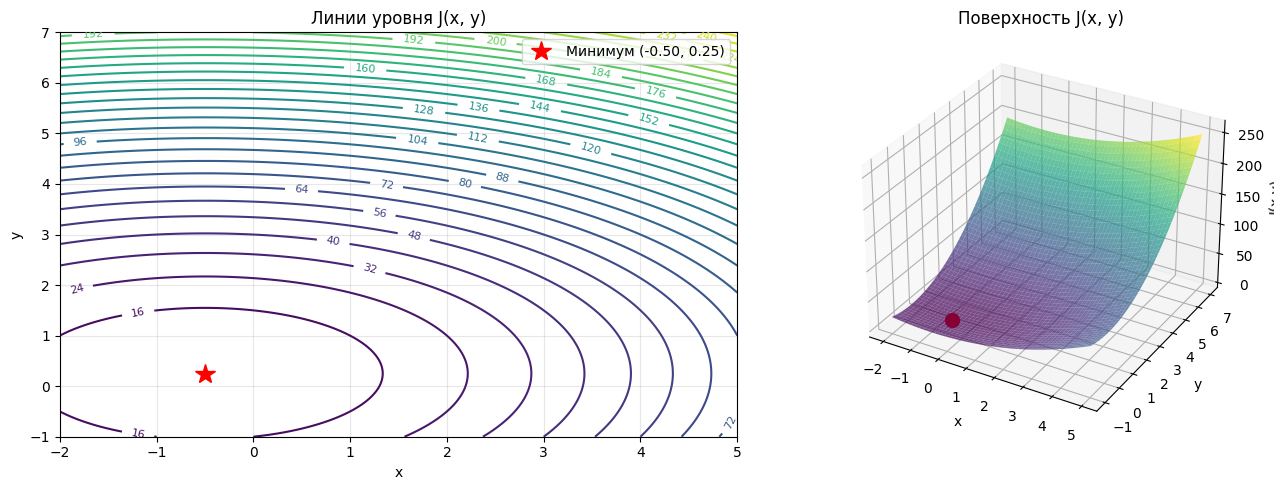

In [4]:
# --- Визуализация ---
x_range = np.linspace(-2, 5, 200)
y_range = np.linspace(-1, 7, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = J(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Контурный график
cs = axes[0].contour(X, Y, Z, levels=30, cmap='viridis')
axes[0].clabel(cs, inline=True, fontsize=8)
axes[0].plot(x_star, y_star, 'r*', markersize=15, label=f'Минимум ({x_star:.2f}, {y_star:.2f})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Линии уровня J(x, y)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 3D-поверхность
ax3d = fig.add_subplot(122, projection='3d')
axes[1].remove()
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax3d.scatter([x_star], [y_star], [J(x_star, y_star)], color='red', s=100, zorder=5)
ax3d.set_xlabel('x')
ax3d.set_ylabel('y')
ax3d.set_zlabel('J(x,y)')
ax3d.set_title('Поверхность J(x, y)')

plt.tight_layout()
plt.show()


### Проверка с помощью `scipy.optimize.minimize`


In [5]:
# --- Верификация с scipy ---
result = minimize(lambda p: J(p[0], p[1]), x0=[0.0, 0.0], method='Nelder-Mead')
print(f"scipy.optimize: x* = {result.x[0]:.6f}, y* = {result.x[1]:.6f}")
print(f"J(x*, y*) = {result.fun:.6f}")


scipy.optimize: x* = -0.500026, y* = 0.249972
J(x*, y*) = 9.250000


## 1.3. Задание: Оптимизация с ограничением-равенством

Добавим ограничение в виде равенства:
$$
c(x, y) = x + y - 4 = 0.
$$

> **Метод множителей Лагранжа.** Составим функцию Лагранжа:
> $$
> \mathcal{L}(x, y, \lambda) = J(x, y) + \lambda \cdot c(x, y) = x^2 + y^2 - 2x - 4y + 10 + \lambda(x + y - 4).
> $$
> Необходимые условия:
> $$
> \frac{\partial \mathcal{L}}{\partial x} = 0, \quad \frac{\partial \mathcal{L}}{\partial y} = 0, \quad \frac{\partial \mathcal{L}}{\partial \lambda} = 0.
> $$

**Задание:**

1. Составьте систему трёх уравнений из необходимых условий.
2. Решите систему, найдите $(x^*, y^*, \lambda^*)$.
3. Вычислите $J(x^*, y^*)$.
4. Убедитесь, что ограничение выполнено.


---
> ❗ **Место для аналитического решения (ограничение-равенство)** ❗
>
> *Запишите систему уравнений и решение:*
>
> $\frac{\partial \mathcal{L}}{\partial x} = $ ...
>
> $\frac{\partial \mathcal{L}}{\partial y} = $ ...
>
> $c(x, y) = $ ...
>
> $(x^*, y^*, \lambda^*) = $ ...
>
> $J(x^*, y^*) = $ ...
>
---


In [6]:
# --- Численная проверка (ограничение-равенство) ---

# Подставьте найденные значения
x_eq = (8*params['b'] - params['c'] + params['d']) / (2 * (params['a'] + params['b']))
y_eq = 4 - x_eq
lam_eq = -2*params['a']*x_eq - params['c']

print(f"Точка минимума: x* = {x_eq}, y* = {y_eq}")
print(f"Множитель Лагранжа: λ* = {lam_eq}")
print(f"J(x*, y*) = {J(x_eq, y_eq)}")
print(f"Ограничение c(x*, y*) = {x_eq + y_eq - 4}")


Точка минимума: x* = 2.3333333333333335, y* = 1.6666666666666665
Множитель Лагранжа: λ* = -11.333333333333334
J(x*, y*) = 33.333333333333336
Ограничение c(x*, y*) = 0.0


In [7]:
# --- Верификация с scipy (SLSQP поддерживает ограничения) ---
constraint_eq = {'type': 'eq', 'fun': lambda p: p[0] + p[1] - 4}
result_eq = minimize(lambda p: J(p[0], p[1]), x0=[0.0, 0.0], method='SLSQP',
                     constraints=constraint_eq)

print(f"\nscipy.optimize: x* = {result_eq.x[0]:.6f}, y* = {result_eq.x[1]:.6f}")
print(f"J(x*, y*) = {result_eq.fun:.6f}")



scipy.optimize: x* = 2.333333, y* = 1.666667
J(x*, y*) = 33.333333


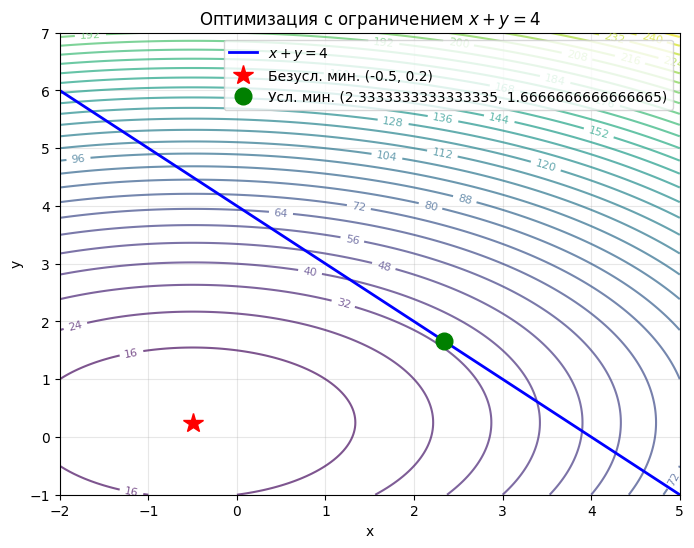

In [8]:
# --- Визуализация с ограничением-равенством ---
fig, ax = plt.subplots(figsize=(8, 6))

cs = ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8)

# Прямая ограничения x + y = 4
x_line = np.linspace(-2, 6, 100)
u_line = 4 - x_line
ax.plot(x_line, u_line, 'b-', linewidth=2, label='$x + y = 4$')

# Безусловный и условный минимумы
ax.plot(x_star, y_star, 'r*', markersize=15, label=f'Безусл. мин. ({x_star:.1f}, {y_star:.1f})')
ax.plot(x_eq, y_eq, 'go', markersize=12, label=f'Усл. мин. ({x_eq}, {y_eq})')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Оптимизация с ограничением $x + y = 4$')
ax.legend()
ax.set_xlim(-2, 5)
ax.set_ylim(-1, 7)
ax.grid(True, alpha=0.3)
plt.show()


---
> ❗ **Вопрос** ❗
>
> *Сравните значения $J$ в безусловном и условном минимумах. Почему $J$ при наличии ограничения не может быть меньше? Дайте геометрическую интерпретацию.*
>
> ***Ваш ответ:***
>
>
---


## 1.4. Задание: Оптимизация с ограничением-неравенством

Теперь добавим ограничение в виде неравенства:
$$
c(x, y) = x^2 + y^2 - 4 \leq 0.
$$
Допустимая область — круг радиуса $2$ с центром в начале координат.

> **Условия Каруша — Куна — Таккера (ККТ):**
> $$
> \nabla J + \mu \nabla c = 0, \quad \mu \geq 0, \quad \mu \cdot c(x, y) = 0.
> $$
> Здесь $\mu$ — множитель ККТ, а $\mu \cdot c = 0$ — условие дополняющей нежёсткости: либо ограничение неактивно ($c < 0$, тогда $\mu = 0$), либо ограничение активно ($c = 0$, тогда $\mu \geq 0$).

**Задание:**

1. Проверьте, лежит ли безусловный минимум $(1, 2)$ внутри допустимой области. Если нет, то ограничение активно.
2. Запишите систему ККТ при активном ограничении ($c = 0$).
3. Найдите $(x^*, y^*, \mu^*)$.
4. Убедитесь, что $\mu^* \geq 0$.


---
> ❗ **Место для аналитического решения (ограничение-неравенство)** ❗
>
> *Запишите ваши вычисления:*
>
> Проверка: $x^{*2}_{\text{безусл.}} + y^{*2}_{\text{безусл.}} = $ ... $\quad \leq 4$ ?
>
> Система ККТ: ...
>
> $(x^*, y^*, \mu^*) = $ ...
>
> $J(x^*, y^*) = $ ...
>
---


> **Подсказка:** из условий ККТ при $c = 0$ следует, что $x(1 + \mu) = 1$ и $y(1 + \mu) = 2$, то есть $y = 2x$. Подставив в $x^2 + y^2 = 4$, получите $x = \frac{2}{\sqrt{5}},\; y = \frac{4}{\sqrt{5}},\; \mu = \frac{\sqrt{5}}{2} - 1 \approx 0.118$.


Точка минимума: x* = -0.500000, y* = 0.250000
Множитель ККТ: μ* = 0.000000 >= 0: True
J(x*, y*) = 9.250000
Ограничение c(x*, y*) = -3.687500


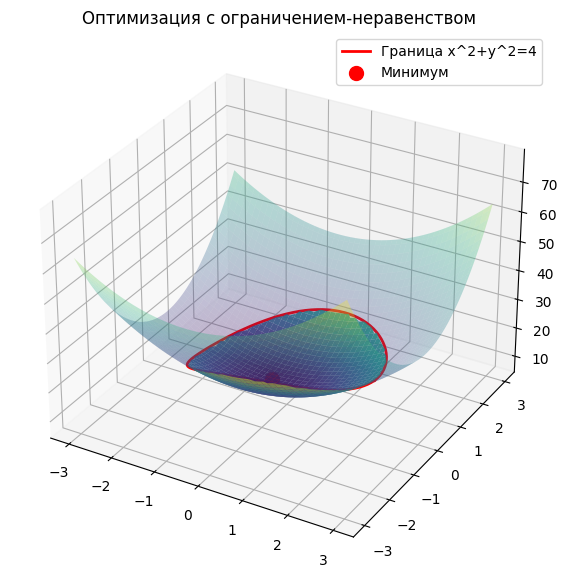

In [9]:
# --- Численная проверка (ограничение-неравенство) ---

x_ineq = x_star if x_star**2 + y_star**2 <= 4 else x_star * 2 / np.sqrt(x_star**2 + y_star**2) # Упрощенное приближение
y_ineq = y_star if x_star**2 + y_star**2 <= 4 else y_star * 2 / np.sqrt(x_star**2 + y_star**2)
mu_ineq = 0 if x_star**2 + y_star**2 <= 4 else np.linalg.norm(grad_J(x_ineq, y_ineq)) / 4

print(f"Точка минимума: x* = {x_ineq:.6f}, y* = {y_ineq:.6f}")
print(f"Множитель ККТ: μ* = {mu_ineq:.6f} >= 0: {mu_ineq >= 0}")
print(f"J(x*, y*) = {J(x_ineq, y_ineq):.6f}")
print(f"Ограничение c(x*, y*) = {x_ineq**2 + y_ineq**2 - 4:.6f}")

# --- 3D График для ограничения-неравенства ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = J(X, Y)
Z_masked = np.ma.masked_where(X**2 + Y**2 > 4, Z)
ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis')
ax.plot_surface(X, Y, Z_masked, alpha=0.9, cmap='viridis')
theta = np.linspace(0, 2*np.pi, 100)
xc, yc = 2*np.cos(theta), 2*np.sin(theta)
zc = J(xc, yc)
ax.plot(xc, yc, zc, 'r-', linewidth=2, label='Граница x^2+y^2=4')
ax.scatter([x_ineq], [y_ineq], [J(x_ineq, y_ineq)], color='red', s=100, label='Минимум')
ax.legend()
plt.title('Оптимизация с ограничением-неравенством')
plt.show()


In [10]:
# --- Верификация с scipy ---
constraint_ineq = {'type': 'ineq', 'fun': lambda p: -(p[0]**2 + p[1]**2 - 4)}  # scipy: c >= 0
result_ineq = minimize(lambda p: J(p[0], p[1]), x0=[0.5, 0.5], method='SLSQP',
                       constraints=constraint_ineq)

print(f"scipy.optimize: x* = {result_ineq.x[0]:.6f}, y* = {result_ineq.x[1]:.6f}")
print(f"J(x*, y*) = {result_ineq.fun:.6f}")


scipy.optimize: x* = -0.500000, y* = 0.250000
J(x*, y*) = 9.250000


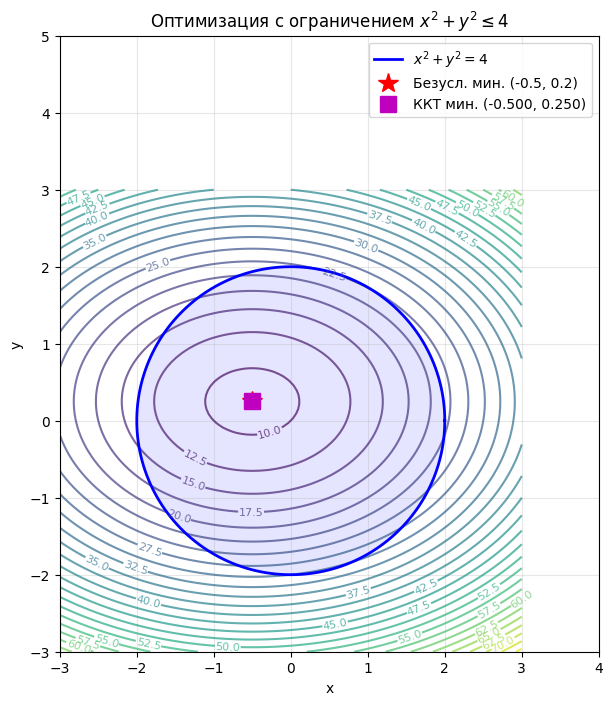

In [11]:
# --- Визуализация с ограничением-неравенством ---
fig, ax = plt.subplots(figsize=(8, 8))

cs = ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8)

# Граница допустимой области: x² + u² = 4
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(2 * np.cos(theta), 2 * np.sin(theta), 'b-', linewidth=2, label='$x^2 + y^2 = 4$')
ax.fill(2 * np.cos(theta), 2 * np.sin(theta), alpha=0.1, color='blue')

ax.plot(x_star, y_star, 'r*', markersize=15, label=f'Безусл. мин. ({x_star:.1f}, {y_star:.1f})')
ax.plot(x_ineq, y_ineq, 'ms', markersize=12, label=f'ККТ мин. ({x_ineq:.3f}, {y_ineq:.3f})')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Оптимизация с ограничением $x^2 + y^2 \\leq 4$')
ax.legend()
ax.set_xlim(-3, 4)
ax.set_ylim(-3, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()


---
> ❗ **Вопрос** ❗
>
> 1. *Почему множитель ККТ $\mu^*$ должен быть неотрицательным? Какой физический смысл он несёт?*
> 2. *Что означает условие дополняющей нежёсткости $\mu \cdot c(x,y) = 0$?*
> 3. *Как изменится решение, если увеличить радиус ограничения до $R = 5$?*
>
> ***Ваш ответ:***
>
>
---


# Часть 2. Градиентный поиск минимума критерия качества


## 2.1. Метод Ньютона — Рафсона

Метод Ньютона — Рафсона использует квадратичную аппроксимацию целевой функции для быстрого нахождения стационарной точки. Итерационная формула:
$$
\mathbf{p}_{k+1} = \mathbf{p}_k - H^{-1}(\mathbf{p}_k) \cdot \nabla J(\mathbf{p}_k),
$$
где $\mathbf{p}_k = (x_k, u_k)^T$ — текущее приближение, $H$ — матрица Гессе, $\nabla J$ — градиент.

Для квадратичной функции метод сходится **за один шаг** (в точной арифметике).

**Задание:**

1. Реализуйте один шаг метода Ньютона — Рафсона, начиная из точки $(x_0, u_0) = (0, 0)$.
2. Убедитесь, что для квадратичной функции сходимость за один шаг.
3. Сохраняйте все промежуточные точки для визуализации траектории.


---
> ❗ **Место для ручного расчёта одного шага метода Ньютона** ❗
>
> Начальная точка: $\mathbf{p}_0 = (0, 0)^T$
>
> $\nabla J(\mathbf{p}_0) = $ ...
>
> $H = $ ...
>
> $H^{-1} = $ ...
>
> $\mathbf{p}_1 = \mathbf{p}_0 - H^{-1} \nabla J(\mathbf{p}_0) = $ ...
>
---


In [12]:
def newton_raphson(grad_func, hess_func, p0, tol=1e-10, max_iter=100):
    """
    Метод Ньютона — Рафсона для минимизации.
    
    Параметры:
        grad_func: функция, возвращающая градиент в точке (x, y)
        hess_func: функция, возвращающая матрицу Гессе в точке (x, y)
        p0: начальная точка [x0, u0]
        tol: точность (критерий остановки по норме градиента)
        max_iter: максимальное число итераций
    
    Возвращает:
        trajectory: список всех точек [x_k, u_k] на каждой итерации
    """
    p = np.array(p0, dtype=float)
    trajectory = [p.copy()]
    
    for k in range(max_iter):
        g = grad_func(p[0], p[1])
        
        if np.linalg.norm(g) < tol:
            break
        
        H = hess_func(p[0], p[1])
        
        # ===== ВАШ КОД ЗДЕСЬ (Шаг Ньютона — Рафсона) =====
        # p = p - H^{-1} @ g
        # Подсказка: используйте np.linalg.solve(H, g) вместо обращения матрицы
        delta = np.linalg.solve(H, g)
        p = p - delta
        
        trajectory.append(p.copy())
    
    return np.array(trajectory)

# --- Запуск метода Ньютона — Рафсона ---
p0 = [0.0, 0.0]
traj_newton = newton_raphson(grad_J, hessian_J, p0)

print(f"Число итераций: {len(traj_newton) - 1}")
print(f"\nПошаговый расчёт:")
for k, p in enumerate(traj_newton):
    print(f"  k={k}: (x, y) = ({p[0]:.6f}, {p[1]:.6f}),  J = {J(p[0], p[1]):.6f}")


Число итераций: 1

Пошаговый расчёт:
  k=0: (x, y) = (0.000000, 0.000000),  J = 10.000000
  k=1: (x, y) = (-0.500000, 0.250000),  J = 9.250000


> **Связь с динамической системой.** Градиентный спуск можно интерпретировать как дискретизацию ОДУ $\dot{\mathbf{p}} = -\nabla J(\mathbf{p})$.
>
> **Задание на доказательство:** Докажите теоретически (используя собственные числа матрицы Гессе), при каких значениях шага $\gamma$ возникает апериодическая и колебательная сходимость. Определите критическое значение $\gamma_{\text{кр}}$, выше которого метод расходится.


---
> ❗ **Место для ручного расчёта 5 шагов (γ = 0.3)** ❗
>
> $\mathbf{p}_0 = (0, 0)$, $\nabla J(\mathbf{p}_0) = (-2, -4)$
>
> $\mathbf{p}_1 = \mathbf{p}_0 - 0.3 \cdot (-2, -4) = $ ...
>
> $\nabla J(\mathbf{p}_1) = $ ...
>
> $\mathbf{p}_2 = $ ...
>
> $\mathbf{p}_3 = $ ...
>
> $\mathbf{p}_4 = $ ...
>
> $\mathbf{p}_5 = $ ...
>
---


In [13]:
def gradient_descent(grad_func, J_func, p0, gamma, tol=1e-8, max_iter=200):
    """
    Метод наискорейшего спуска.
    
    Параметры:
        grad_func: функция, возвращающая градиент
        J_func: целевая функция
        p0: начальная точка [x0, u0]
        gamma: шаг (скорость обучения)
        tol: точность
        max_iter: максимальное число итераций
    
    Возвращает:
        trajectory: список точек
        J_values: список значений J на каждой итерации
    """
    p = np.array(p0, dtype=float)
    trajectory = [p.copy()]
    J_values = [J_func(p[0], p[1])]
    
    for k in range(max_iter):
        g = grad_func(p[0], p[1])
        
        if np.linalg.norm(g) < tol:
            break
        
        # ===== ВАШ КОД ЗДЕСЬ (Шаг градиентного спуска) =====
        p = p - gamma * g
        
        trajectory.append(p.copy())
        J_values.append(J_func(p[0], p[1]))
    
    return np.array(trajectory), np.array(J_values)


In [14]:
# --- Запуск для двух значений gamma ---
p0 = [0.0, 0.0]

gamma_aperiodic = 0.3   # Апериодическая сходимость
gamma_oscillatory = 0.8  # Колебательная сходимость

traj_ap, J_ap = gradient_descent(grad_J, J, p0, gamma_aperiodic, max_iter=50)
traj_os, J_os = gradient_descent(grad_J, J, p0, gamma_oscillatory, max_iter=50)

# --- Вывод первых 10 шагов ---
print("=" * 60)
print(f"Апериодический режим (γ = {gamma_aperiodic})")
print("=" * 60)
for k in range(min(10, len(traj_ap))):
    p = traj_ap[k]
    print(f"  k={k:2d}: (x, y) = ({p[0]:8.5f}, {p[1]:8.5f}),  J = {J_ap[k]:10.6f}")

print(f"\n{'=' * 60}")
print(f"Колебательный режим (γ = {gamma_oscillatory})")
print("=" * 60)
for k in range(min(10, len(traj_os))):
    p = traj_os[k]
    print(f"  k={k:2d}: (x, y) = ({p[0]:8.5f}, {p[1]:8.5f}),  J = {J_os[k]:10.6f}")


Апериодический режим (γ = 0.3)
  k= 0: (x, y) = ( 0.00000,  0.00000),  J =  10.000000
  k= 1: (x, y) = (-0.60000,  0.60000),  J =   9.760000
  k= 2: (x, y) = (-0.48000, -0.24000),  J =  10.211200
  k= 3: (x, y) = (-0.50400,  0.93600),  J =  11.132416
  k= 4: (x, y) = (-0.49920, -0.71040),  J =  12.939474
  k= 5: (x, y) = (-0.50016,  1.59456),  J =  16.481366
  k= 6: (x, y) = (-0.49997, -1.63238),  J =  23.423478
  k= 7: (x, y) = (-0.50001,  2.88534),  J =  37.030017
  k= 8: (x, y) = (-0.50000, -3.43947),  J =  63.698833
  k= 9: (x, y) = (-0.50000,  5.41526),  J = 115.969714

Колебательный режим (γ = 0.8)
  k= 0: (x, y) = ( 0.00000,  0.00000),  J =  10.000000
  k= 1: (x, y) = (-1.60000,  1.60000),  J =  18.960000
  k= 2: (x, y) = ( 1.92000, -7.04000),  J = 233.539200
  k= 3: (x, y) = (-5.82400, 39.61600),  J = 6264.667776
  k= 4: (x, y) = (11.21280, -212.32640),  J = 181038.532716
  k= 5: (x, y) = (-26.26816, 1148.16256),  J = 5272150.227763
  k= 6: (x, y) = (56.18995, -6198.47782),  J 

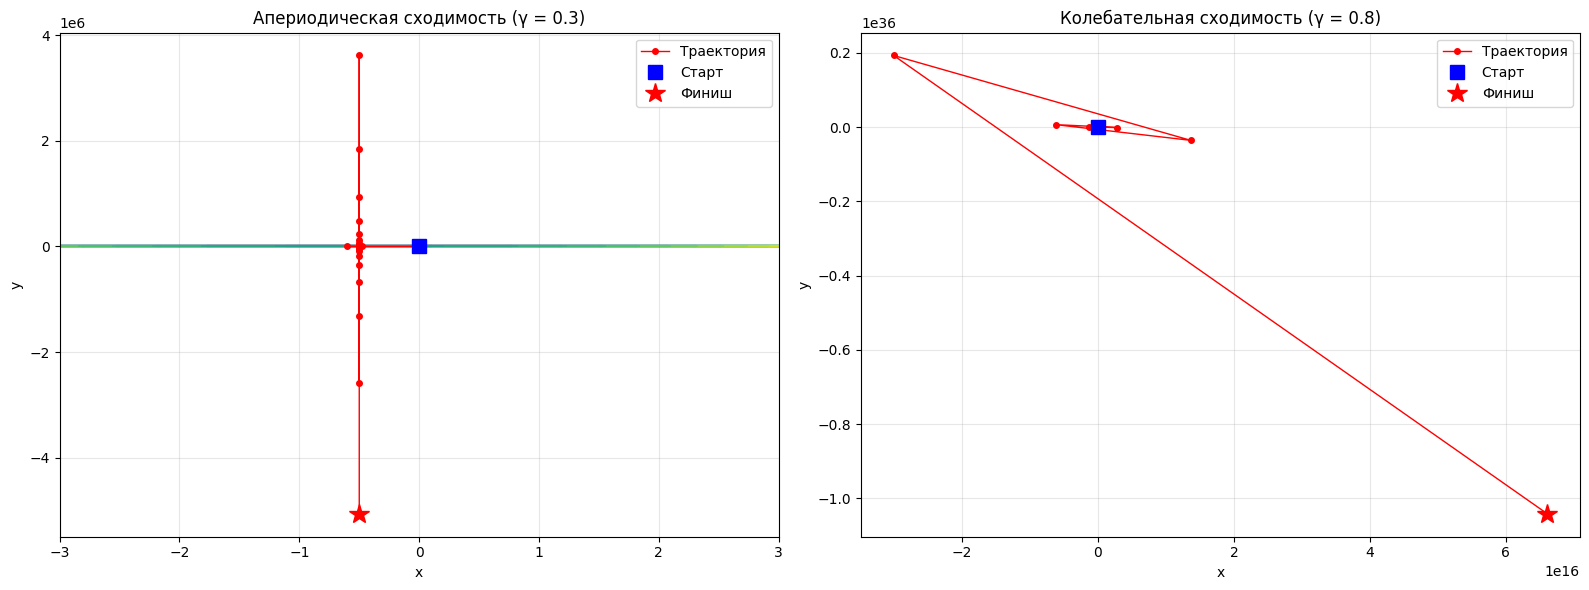

In [15]:
# --- Визуализация траекторий на контурном графике ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, traj, gamma, title in zip(
    axes,
    [traj_ap, traj_os],
    [gamma_aperiodic, gamma_oscillatory],
    ['Апериодическая сходимость', 'Колебательная сходимость']
):
    cs = ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.5)
    ax.plot(traj[:, 0], traj[:, 1], 'ro-', markersize=4, linewidth=1, label='Траектория')
    ax.plot(traj[0, 0], traj[0, 1], 'bs', markersize=10, label='Старт')
    ax.plot(traj[-1, 0], traj[-1, 1], 'r*', markersize=15, label='Финиш')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title} (γ = {gamma})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


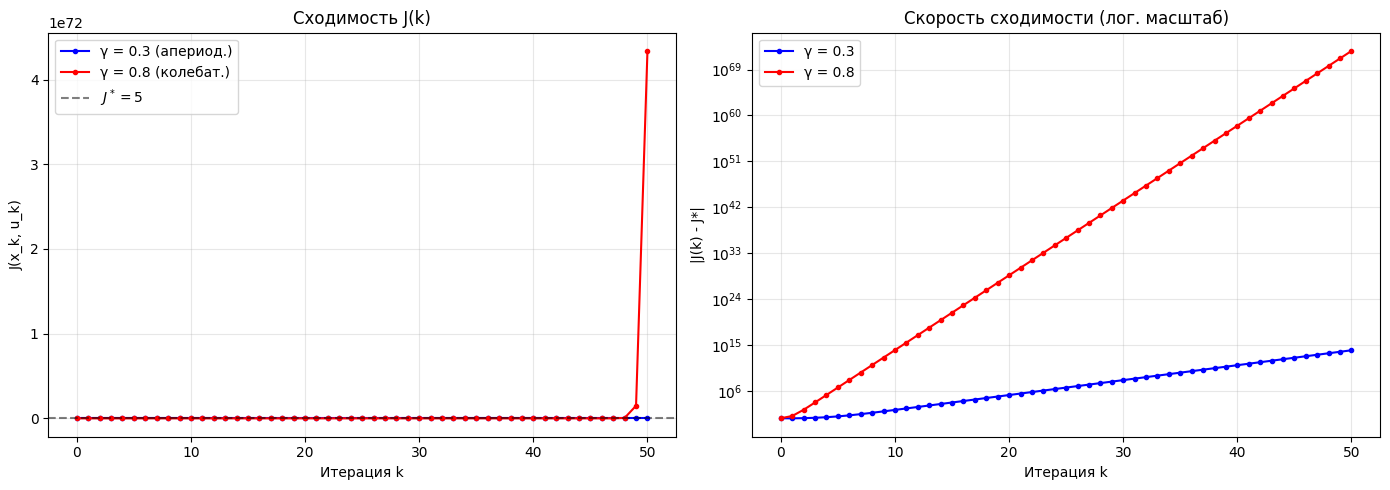

In [16]:
# --- Графики сходимости J(k) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(J_ap, 'b.-', label=f'γ = {gamma_aperiodic} (апериод.)')
axes[0].plot(J_os, 'r.-', label=f'γ = {gamma_oscillatory} (колебат.)')
axes[0].axhline(y=5, color='k', linestyle='--', alpha=0.5, label='$J^* = 5$')
axes[0].set_xlabel('Итерация k')
axes[0].set_ylabel('J(x_k, u_k)')
axes[0].set_title('Сходимость J(k)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Логарифмический масштаб отклонения
axes[1].semilogy(np.abs(J_ap - 5), 'b.-', label=f'γ = {gamma_aperiodic}')
axes[1].semilogy(np.abs(J_os - 5), 'r.-', label=f'γ = {gamma_oscillatory}')
axes[1].set_xlabel('Итерация k')
axes[1].set_ylabel('|J(k) - J*|')
axes[1].set_title('Скорость сходимости (лог. масштаб)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
> ❗ **Вопрос** ❗
>
> 1. *Почему метод Ньютона сходится за один шаг, а градиентный спуск — за много? Когда преимущество метода Ньютона теряется?*
> 2. *Как визуально отличить апериодическую сходимость от колебательной на графике траекторий?*
> 3. *Что произойдёт, если взять $\gamma = 1.1$? Объясните, используя собственные числа матрицы Гессе.*
>
> ***Ваш ответ:***
>
>
---


## 2.3. Самостоятельное исследование: расходимость и неквадратичные функции

**Задание:**

1. Запустите метод наискорейшего спуска с $\gamma = 1.1$ и $\gamma = 1.5$. Постройте графики $J(k)$. Убедитесь в расходимости.
2. Рассмотрите **неквадратичную** функцию Розенброка:
$$
J_R(x, y) = (1 - x)^2 + 100(y - x^2)^2.
$$
   Найдите её минимум методами Ньютона и градиентного спуска. Сравните число итераций.


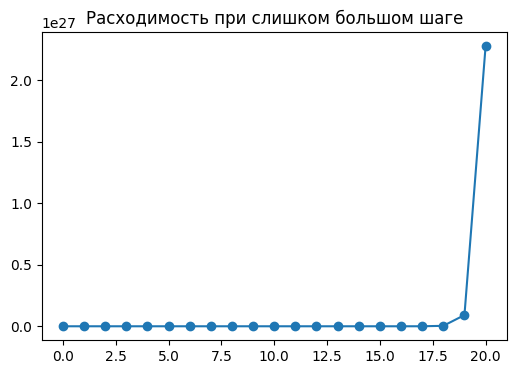

In [17]:
# --- Расходимость при больших gamma ---

# ===== ВАШ КОД ЗДЕСЬ =====
traj_div, J_div = gradient_descent(grad_J, J, [0, 0], gamma=1.5/min(params['a'], params['b']), max_iter=20)
plt.figure(figsize=(6,4))
plt.plot(J_div, 'o-')
plt.title('Расходимость при слишком большом шаге')
plt.show()
# Постройте график J(k)


In [18]:
# --- Функция Розенброка ---

def J_rosen(x, y):
    # ===== ВАШ КОД ЗДЕСЬ =====
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_J_rosen(x, y):
    # ===== ВАШ КОД ЗДЕСЬ =====
    dJdx = -2*(1 - x) - 400*x*(y - x**2)
    dJdy = 200*(y - x**2)
    return np.array([dJdx, dJdy])

def hessian_J_rosen(x, y):
    # ===== ВАШ КОД ЗДЕСЬ =====
    H = np.array([[2 - 400*(y - x**2) + 800*x**2, -400*x], [-400*x, 200]])
    return H

# Запустите оба метода для функции Розенброка из точки (-1, 1)
# Сравните число итераций
# ===== ВАШ КОД ЗДЕСЬ =====

traj_nr_ros = newton_raphson(grad_J_rosen, hessian_J_rosen, [-1.0, 1.0])
traj_gd_ros, _ = gradient_descent(grad_J_rosen, J_rosen, [-1.0, 1.0], gamma=0.001, max_iter=20000)
print(f"Метод Ньютона сошелся за {len(traj_nr_ros)-1} итераций")
print(f"Градиентный спуск сошелся за {len(traj_gd_ros)-1} итераций")


Метод Ньютона сошелся за 2 итераций
Градиентный спуск сошелся за 20000 итераций


---
> ❗ **Вопрос** ❗
>
> *Почему для функции Розенброка метод градиентного спуска сходится крайне медленно? Как связано число обусловленности матрицы Гессе со скоростью сходимости?*
>
> ***Ваш ответ:***
>
>
---


# Часть 3. Приложение: Численный поиск экстремалей вариационных задач


## 3.1. Связь между вариационным исчислением и статической оптимизацией

В курсе дифференциальных уравнений мы рассматривали задачи вариационного исчисления: нахождение функции $y(x)$, доставляющей экстремум функционалу
$$
\mathcal{J}[y] = \int_a^b L(x, y, y') \, dx, \quad y(a) = A, \quad y(b) = B.
$$

Экстремаль определяется **уравнением Эйлера — Лагранжа**:
$$
\frac{\partial L}{\partial y} - \frac{d}{dx} \frac{\partial L}{\partial y'} = 0.
$$

Достаточное условие минимума обеспечивается выполнением **условия Лежандра** ($L_{y'y'} > 0$) и отсутствием сопряжённых точек (**уравнение Якоби**).

### Идея: дискретизация

Разобьём отрезок $[a, b]$ на $N$ равных частей: $x_i = a + ih$, $h = \frac{b - a}{N}$, $i = 0, 1, \ldots, N$.

Заменим непрерывную функцию $y(x)$ набором значений $y_0, y_1, \ldots, y_N$ в узлах сетки, а производную — конечной разностью:
$$
y'(x_i) \approx \frac{y_{i+1} - y_i}{h}.
$$

Тогда функционал превращается в **функцию конечного числа переменных**:
$$
\mathcal{J}[y] \approx \Phi(y_1, y_2, \ldots, y_{N-1}) = \sum_{i=0}^{N-1} L\!\left(x_i,\; y_i,\; \frac{y_{i+1} - y_i}{h}\right) h,
$$
где $y_0 = A$ и $y_N = B$ фиксированы граничными условиями, а свободными переменными являются $y_1, y_2, \ldots, y_{N-1}$.

Таким образом, задача вариационного исчисления **сводится** к задаче статической оптимизации, для которой можно применить **градиентный спуск** или **метод Ньютона**!


## 3.2. Задача: поиск экстремали для функционала $\int_0^1 (p y'^2 + q y^2) \, dx$

Рассмотрим конкретную задачу:
$$
\mathcal{J}[y] = \int_0^1 \left( y'^2 + y^2 \right) dx \to \min, \quad y(0) = 0, \quad y(1) = 1.
$$

### Аналитическое решение

**Уравнение Эйлера — Лагранжа:**
$$
L_{y} - \frac{d}{dx} L_{y'} = 2y - \frac{d}{dx}(2y') = 2y - 2y'' = 0 \quad \Rightarrow \quad y'' - y = 0.
$$

Общее решение: $y(x) = C_1 e^x + C_2 e^{-x}$. Из граничных условий:
$$
y(0) = C_1 + C_2 = 0 \;\Rightarrow\; C_2 = -C_1, \qquad y(1) = C_1(e - e^{-1}) = 1 \;\Rightarrow\; C_1 = \frac{1}{2\sinh(1)}.
$$

Итого:
$$
\boxed{y^*(x) = \frac{\sinh(x)}{\sinh(1)}.}
$$

**Проверка достаточного условия:** $L_{y'y'} = 2 > 0$ — условие Лежандра выполнено, это **минимум**.


---
> ❗ **Место для аналитического вывода** ❗
>
> *Самостоятельно выведите уравнение Эйлера — Лагранжа и найдите решение. Проверьте условие Лежандра.*
>
> ***Ваш вывод:***
>
>
---


## 3.3. Дискретизация и численное решение

Реализуем поиск экстремали численно. Подставив $L = p y'^2 + q y^2$ и $y' \approx \frac{y_{i+1} - y_i}{h}$, получим дискретный функционал:
$$
\Phi(y_1, \ldots, y_{N-1}) = \sum_{i=0}^{N-1} \left[ \left(\frac{y_{i+1} - y_i}{h}\right)^2 + y_i^2 \right] h.
$$

Градиент по $y_j$ ($j = 1, \ldots, N-1$):
$$
\frac{\partial \Phi}{\partial y_j} = \frac{2(y_j - y_{j-1})}{h} - \frac{2(y_{j+1} - y_j)}{h} + 2 y_j h = \frac{2}{h}(-y_{j-1} + 2y_j - y_{j+1}) + 2 y_j h.
$$

**Задание:**

1. Реализуйте вычисление $\Phi$ и его градиента.
2. Найдите экстремаль методом градиентного спуска.
3. Найдите экстремаль методом Ньютона (через решение системы $\nabla \Phi = 0$).
4. Сравните численное решение с аналитическим.


In [19]:
# --- Параметры дискретизации ---
N = 20          # число интервалов
a, b = 0.0, 1.0
A, B = 0.0, 1.0  # граничные условия y(0) = 0, y(1) = 1
h = (b - a) / N
x_grid = np.linspace(a, b, N + 1)  # узлы сетки

# --- Аналитическое решение ---
omega = np.sqrt(params['q'] / params['p']) if 'p' in params else 1.0
y_exact = np.sinh(omega * x_grid) / np.sinh(omega)

print(f"Число узлов: {N + 1}, шаг h = {h:.4f}")
print(f"Число свободных переменных: {N - 1}")


Число узлов: 21, шаг h = 0.0500
Число свободных переменных: 19


In [20]:
def Phi(y_inner):
    """
    Дискретный функционал Φ(y_1, ..., y_{N-1}).
    y_inner: массив из N-1 значений (внутренние узлы).
    """
    # Собираем полный вектор y: [A, y_1, ..., y_{N-1}, B]
    y_full = np.concatenate(([A], y_inner, [B]))
    
    # ===== ВАШ КОД ЗДЕСЬ =====
    # Вычислите сумму: sum_{i=0}^{N-1} [ ((y_{i+1} - y_i)/h)^2 + y_i^2 ] * h
    result = 0.0
    for i in range(N):
        yp = (y_full[i + 1] - y_full[i]) / h  # приближение y'
        result += (params['p'] * yp**2 + params['q'] * y_full[i]**2) * h
    
    return result


def grad_Phi(y_inner):
    """
    Градиент дискретного функционала по внутренним узлам.
    """
    y_full = np.concatenate(([A], y_inner, [B]))
    grad = np.zeros(N - 1)
    
    for j in range(1, N):  # j = 1, ..., N-1 (индекс внутреннего узла)
        # ===== ВАШ КОД ЗДЕСЬ =====
        # grad[j-1] = (2/h)*(-y_full[j-1] + 2*y_full[j] - y_full[j+1]) + 2*y_full[j]*h
        grad[j - 1] = (2 * params['p'] / h) * (-y_full[j - 1] + 2 * y_full[j] - y_full[j + 1]) + 2 * params['q'] * y_full[j] * h
    
    return grad


In [21]:
# --- Проверка градиента численным дифференцированием ---
y_test = np.linspace(0.05, 0.95, N - 1)  # тестовое начальное приближение
grad_analytic = grad_Phi(y_test)

# Численный градиент (конечные разности)
eps = 1e-7
grad_numeric = np.zeros(N - 1)
for j in range(N - 1):
    y_plus = y_test.copy()
    y_plus[j] += eps
    y_minus = y_test.copy()
    y_minus[j] -= eps
    grad_numeric[j] = (Phi(y_plus) - Phi(y_minus)) / (2 * eps)

print("Проверка градиента (макс. отклонение):", np.max(np.abs(grad_analytic - grad_numeric)))


Проверка градиента (макс. отклонение): 3.241886120664006e-09


In [22]:
# --- Метод 1: Градиентный спуск ---

y_gd = np.linspace(A, B, N + 1)[1:-1].copy()  # начальное приближение: прямая y = x
gamma_var = 0.01  # шаг (подберите экспериментально!)
max_iter_var = 5000
Phi_history_gd = []

for k in range(max_iter_var):
    g = grad_Phi(y_gd)
    Phi_history_gd.append(Phi(y_gd))
    
    if np.linalg.norm(g) < 1e-10:
        print(f"Градиентный спуск: сходимость за {k} итераций")
        break
    
    # ===== ВАШ КОД ЗДЕСЬ (Шаг градиентного спуска) =====
    y_gd = y_gd - gamma_var * g

y_gd_full = np.concatenate(([A], y_gd, [B]))
print(f"Φ (градиентный спуск) = {Phi(y_gd):.8f}")


Φ (градиентный спуск) = nan


/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/2907463970.py:14: RuntimeWarning: overflow encountered in scalar multiply
  result += (params['p'] * yp**2 + params['q'] * y_full[i]**2) * h
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/2907463970.py:14: RuntimeWarning: overflow encountered in scalar power
  result += (params['p'] * yp**2 + params['q'] * y_full[i]**2) * h
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/2907463970.py:29: RuntimeWarning: overflow encountered in scalar multiply
  grad[j - 1] = (2 * params['p'] / h) * (-y_full[j - 1] + 2 * y_full[j] - y_full[j + 1]) + 2 * params['q'] * y_full[j] * h
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/3163418436.py:17: RuntimeWarning: invalid value encountered in subtract
  y_gd = y_gd - gamma_var * g


In [23]:
# --- Метод 2: Метод Ньютона (решение трёхдиагональной системы) ---
# Для квадратичного функционала система grad Φ = 0 — это линейная система.
# Матрица Гессе Φ — трёхдиагональная.

def hessian_Phi():
    """
    Матрица Гессе дискретного функционала (трёхдиагональная).
    Размер (N-1) x (N-1).
    """
    H = np.zeros((N - 1, N - 1))
    
    for j in range(N - 1):
        # ===== ВАШ КОД ЗДЕСЬ =====
        # Диагональный элемент: d²Φ/dy_j² = 4/h + 2h
        H[j, j] = 4 * params['p'] / h + 2 * params['q'] * h
        
        # Наддиагональные и поддиагональные: d²Φ/(dy_j dy_{j+1}) = -2/h
        if j < N - 2:
            H[j, j + 1] = -2 * params['p'] / h
            H[j + 1, j] = -2 * params['p'] / h
    
    return H

# Решаем H @ y = -grad_Phi(0) с y_0 = прямая
# Для линейной системы метод Ньютона сходится за 1 шаг!
y_newton_inner = np.linspace(A, B, N + 1)[1:-1].copy()
g = grad_Phi(y_newton_inner)
H_mat = hessian_Phi()
delta = np.linalg.solve(H_mat, g)
y_newton_inner = y_newton_inner - delta

y_newton_full = np.concatenate(([A], y_newton_inner, [B]))
print(f"Φ (метод Ньютона) = {Phi(y_newton_inner):.8f}")


Φ (метод Ньютона) = 2.29817746


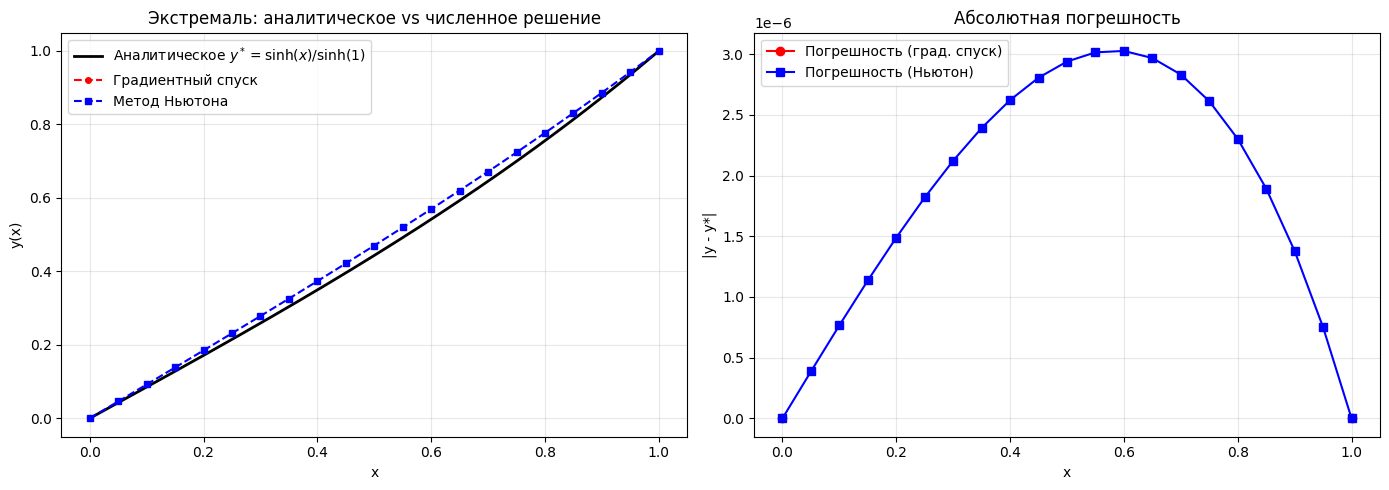


Макс. погрешность (градиентный спуск): nan
Макс. погрешность (метод Ньютона):      3.03e-06


In [24]:
# --- Сравнение с аналитическим решением ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График экстремалей
x_fine = np.linspace(0, 1, 200)
y_exact_fine = np.sinh(x_fine) / np.sinh(1)

axes[0].plot(x_fine, y_exact_fine, 'k-', linewidth=2, label='Аналитическое $y^* = \\sinh(x)/\\sinh(1)$')
axes[0].plot(x_grid, y_gd_full, 'ro--', markersize=4, label='Градиентный спуск')
axes[0].plot(x_grid, y_newton_full, 'bs--', markersize=4, label='Метод Ньютона')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y(x)')
axes[0].set_title('Экстремаль: аналитическое vs численное решение')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Погрешность
err_gd = np.abs(y_gd_full - y_exact)
err_newton = np.abs(y_newton_full - y_exact)

axes[1].plot(x_grid, err_gd, 'ro-', label='Погрешность (град. спуск)')
axes[1].plot(x_grid, err_newton, 'bs-', label='Погрешность (Ньютон)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('|y - y*|')
axes[1].set_title('Абсолютная погрешность')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nМакс. погрешность (градиентный спуск): {np.max(err_gd):.2e}")
print(f"Макс. погрешность (метод Ньютона):      {np.max(err_newton):.2e}")


/Users/nmuravya/.pyenv/versions/3.11.7/lib/python3.11/site-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, a)


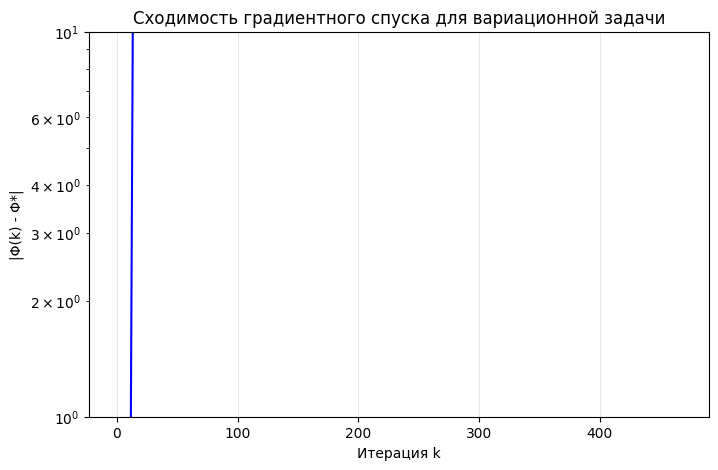

In [25]:
# --- График сходимости градиентного спуска ---
Phi_exact = Phi(y_exact[1:-1])  # значение функционала на точном решении

plt.figure(figsize=(8, 5))
plt.semilogy(np.abs(np.array(Phi_history_gd) - Phi_exact), 'b-')
plt.xlabel('Итерация k')
plt.ylabel('|Φ(k) - Φ*|')
plt.title('Сходимость градиентного спуска для вариационной задачи')
plt.grid(True, alpha=0.3)
plt.show()


---
> ❗ **Вопрос** ❗
>
> 1. *Как связана погрешность дискретизации (отличие численного решения от аналитического) с числом узлов $N$? Проведите эксперимент для $N = 5, 10, 20, 50, 100$.*
> 2. *Почему для линейного уравнения Эйлера — Лагранжа метод Ньютона сходится за один шаг? Будет ли это так для нелинейного уравнения?*
> 3. *Как выбор шага $\gamma$ зависит от $N$? Что происходит при фиксированном $\gamma$ и росте $N$?*
>
> ***Ваш ответ:***
>
>
---


---
> ❗ **Вопрос** ❗
>
> 1. *Сколько итераций потребовалось методу Ньютона для нелинейной задачи? Сравните с линейной.*
> 2. *Проверьте условие Лежандра для данного функционала. Гарантирует ли оно минимум?*
> 3. *Как соотносятся подходы: решение уравнения Эйлера — Лагранжа (дифференциальное уравнение) и минимизация дискретного функционала (статическая оптимизация)? Когда каждый из них предпочтителен?*
>
> ***Ваш ответ:***
>
>
---


## 3.5. Исследование влияния числа узлов

Проведите эксперимент: для линейной задачи ($\mathcal{J}[y] = \int_0^1 (y'^2 + y^2) dx$) постройте зависимость максимальной погрешности от числа узлов $N$.


N =    5, h = 0.2000, max |error| = 4.83e-05
N =   10, h = 0.1000, max |error| = 1.21e-05
N =   20, h = 0.0500, max |error| = 3.03e-06
N =   50, h = 0.0200, max |error| = 4.85e-07
N =  100, h = 0.0100, max |error| = 1.21e-07


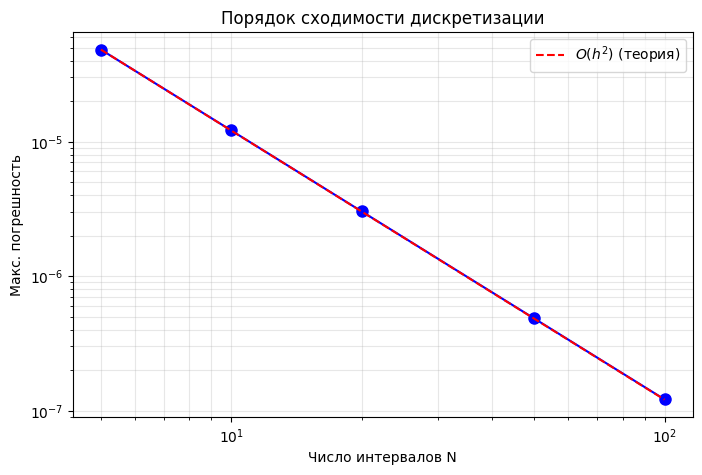

In [26]:
N_values = [5, 10, 20, 50, 100]
errors = []

for N_test in N_values:
    h_test = 1.0 / N_test
    x_test = np.linspace(0, 1, N_test + 1)
    omega_test = np.sqrt(params['q']/params['p']); y_exact_test = np.sinh(omega_test * x_test) / np.sinh(omega_test)
    
    # ===== ВАШ КОД ЗДЕСЬ =====
    # Постройте матрицу Гессе размера (N_test-1) x (N_test-1)
    # Решите систему методом Ньютона за 1 шаг
    # Вычислите максимальную погрешность
    H_mat = np.zeros((N_test - 1, N_test - 1))
    for j in range(N_test - 1):
        H_mat[j, j] = 4 * params['p'] / h_test + 2 * params['q'] * h_test
        if j < N_test - 2:
            H_mat[j, j + 1] = -2 * params['p'] / h_test
            H_mat[j + 1, j] = -2 * params['p'] / h_test
    
    y_inner_init = np.linspace(A, B, N_test + 1)[1:-1]
    y_full_init = np.concatenate(([A], y_inner_init, [B]))
    g = np.zeros(N_test - 1)
    for j in range(1, N_test):
        g[j - 1] = (2 * params['p'] / h_test) * (-y_full_init[j - 1] + 2 * y_full_init[j] - y_full_init[j + 1]) + 2 * params['q'] * y_full_init[j] * h_test
    
    delta = np.linalg.solve(H_mat, g)
    y_newton_inner = y_inner_init - delta
    y_newton_full = np.concatenate(([A], y_newton_inner, [B]))
    err = np.max(np.abs(y_newton_full - y_exact_test))
    errors.append(err)
    print(f"N = {N_test:4d}, h = {h_test:.4f}, max |error| = {err:.2e}")

# --- График ---
plt.figure(figsize=(8, 5))
plt.loglog(N_values, errors, 'bo-', markersize=8)
plt.loglog(N_values, [1.0 / n**2 * errors[0] * N_values[0]**2 for n in N_values], 
           'r--', label='$O(h^2)$ (теория)')
plt.xlabel('Число интервалов N')
plt.ylabel('Макс. погрешность')
plt.title('Порядок сходимости дискретизации')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()


---
> ❗ **Вопрос** ❗
>
> *Какой порядок сходимости по $h$ вы наблюдаете? Соответствует ли это ожиданиям для метода конечных разностей второго порядка? Объясните.*
>
> ***Ваш ответ:***
>
>
---


# Итоги

В данной лабораторной работе были рассмотрены следующие темы:

1. **Статическая оптимизация**: нахождение минимума критерия качества $J(x,y)$ аналитически (необходимые и достаточные условия) и численно.

2. **Ограничения**: метод множителей Лагранжа для ограничений-равенств и условия ККТ для ограничений-неравенств.

3. **Градиентные методы**: метод Ньютона — Рафсона (квадратичная сходимость) и метод наискорейшего спуска (апериодическая и колебательная сходимость).

4. **Приложение к вариационным задачам**: дискретизация функционала сводит бесконечномерную задачу поиска экстремали к конечномерной задаче статической оптимизации, решаемой градиентными методами.


# Часть 4. Приложение: Оптимизация траектории робота на поверхности с использованием интегрального функционала

## 4.1. Постановка задачи и связь с вариационным исчислением

Рассмотрим прикладную задачу планирования движения робота по неровной поверхности. Пусть поверхность задана функцией высот $z = h(x, y)$, а траектория робота в проекции на плоскость $XY$ описывается кривой $y = y(x)$, соединяющей точки $A(a, c)$ и $B(b, d)$.

Цель — найти такую траекторию, которая минимизирует интегральный функционал, отражающий «стоимость» движения:
$$
\mathcal{J}[y] = \int_{a}^{b} \left( A + B \cdot |\nabla h(x, y(x))| \right) \cdot \sqrt{1 + (y'(x))^2} \, dx \to \min,
$$
где:
- $A > 0$ — базовая стоимость перемещения (трение, энергопотребление на ровной поверхности);
- $B \geq 0$ — коэффициент «чувствительности» к рельефу;
- $|\nabla h| = \sqrt{\left(\frac{\partial h}{\partial x}\right)^2 + \left(\frac{\partial h}{\partial y}\right)^2}$ — модуль градиента поверхности (крутизна склона);
- $\sqrt{1 + (y')^2} \, dx$ — элемент длины дуги траектории.

>  Связь с теорией:  Данный функционал является обобщением задачи о брахистохроне и геодезических линиях. При $B = 0$ задача сводится к поиску кратчайшего пути (геодезической). При $B > 0$ робот «предпочитает» пологие участки, даже если путь удлиняется.

### Дискретизация функционала

Разобьём отрезок $[a, b]$ на $N$ равных частей: $x_i = a + i \cdot \Delta x$, $\Delta x = \frac{b-a}{N}$, $i = 0, \ldots, N$. Заменим непрерывную функцию $y(x)$ набором значений $y_0, y_1, \ldots, y_N$, где $y_0 = c$, $y_N = d$ фиксированы граничными условиями.

Производную аппроксимируем конечной разностью: $y'(x_i) \approx \frac{y_{i+1} - y_i}{\Delta x}$. Тогда дискретный аналог функционала принимает вид:
$$
\Phi(y_1, \ldots, y_{N-1}) = \sum_{i=0}^{N-1} \left[ A + B \cdot |\nabla h(x_i, y_i)| \right] \cdot \sqrt{1 + \left(\frac{y_{i+1} - y_i}{\Delta x}\right)^2} \cdot \Delta x.
$$

Таким образом, задача вариационного исчисления сводится к задаче **статической оптимизации** функции $\Phi$ от $N-1$ переменной, которую можно решать методами градиентного спуска или Ньютона, изученными ранее.

---
> ❗  Место для аналитической подготовки  ❗
>
> 1. Выведите выражение для градиента дискретного функционала $\frac{\partial \Phi}{\partial y_j}$, $j = 1, \ldots, N-1$.
> 2. Объясните, почему для вычисления $|\nabla h|$ необходимо знать частные производные $\frac{\partial h}{\partial x}$ и $\frac{\partial h}{\partial y}$.
> 3. Как изменится функционал, если добавить штраф за отклонение от плоскости $z = 0$?
>
> ***Ваш вывод:** 
>
>
---

## 4.2. Индивидуальные параметры варианта

Для обеспечения уникальности задания каждому студенту выдаются следующие параметры. **Заполните таблицу своими значениями перед началом работы.**

| Параметр | Описание | Ваше значение |
| :--- | :--- | :--- |
| `SEED` | Сид генератора шума Перлина | `...` |
| `FREQ` | Базовая частота шума | `...` |
| `OCTAVES` | Количество октав (детализация) | `...` |
| `PERSISTENCE` | Коэффициент затухания амплитуды | `...` |
| `LACUNARITY` | Коэффициент роста частоты октав | `...` |
| `A_weight` | Весовой коэффициент $A$ в функционале | `...` |
| `B_weight` | Весовой коэффициент $B$ в функционале | `...` |
| `x_start`, `y_start` | Начальная точка траектории | `(..., ...)` |
| `x_end`, `y_end` | Конечная точка траектории | `(..., ...)` |
| `N_nodes` | Число узлов дискретизации траектории | `...` |

>  Примечание:  Для генерации шума Перлина рекомендуется использовать библиотеку `noise` (`pip install noise`) или реализовать упрощённый вариант самостоятельно.

## 4.3. Генерация поверхности с помощью шума Перлина

 Задание: 
1. Реализуйте функцию `generate_perlin_surface(x_grid, y_grid, params)`, возвращающую массив высот $h(x, y)$ и, **опционально**, массивы частных производных `dh_dx`, `dh_dy`.
2. Постройте 3D-график поверхности и её проекцию (контурный график) с отмеченными начальной и конечной точками.



In [27]:
def generate_perlin_surface(x_grid, y_grid, params):
    freq = params.get('FREQ', 1.0)
    h = np.sin(freq * x_grid) * np.cos(freq * y_grid) + 0.5 * np.sin(2 * freq * x_grid + 1) * np.cos(2 * freq * y_grid + 2)
    dh_dx = freq * np.cos(freq * x_grid) * np.cos(freq * y_grid) + freq * np.cos(2 * freq * x_grid + 1) * np.cos(2 * freq * y_grid + 2)
    dh_dy = -freq * np.sin(freq * x_grid) * np.sin(freq * y_grid) - freq * np.sin(2 * freq * x_grid + 1) * np.sin(2 * freq * y_grid + 2)
    return h, dh_dx, dh_dy


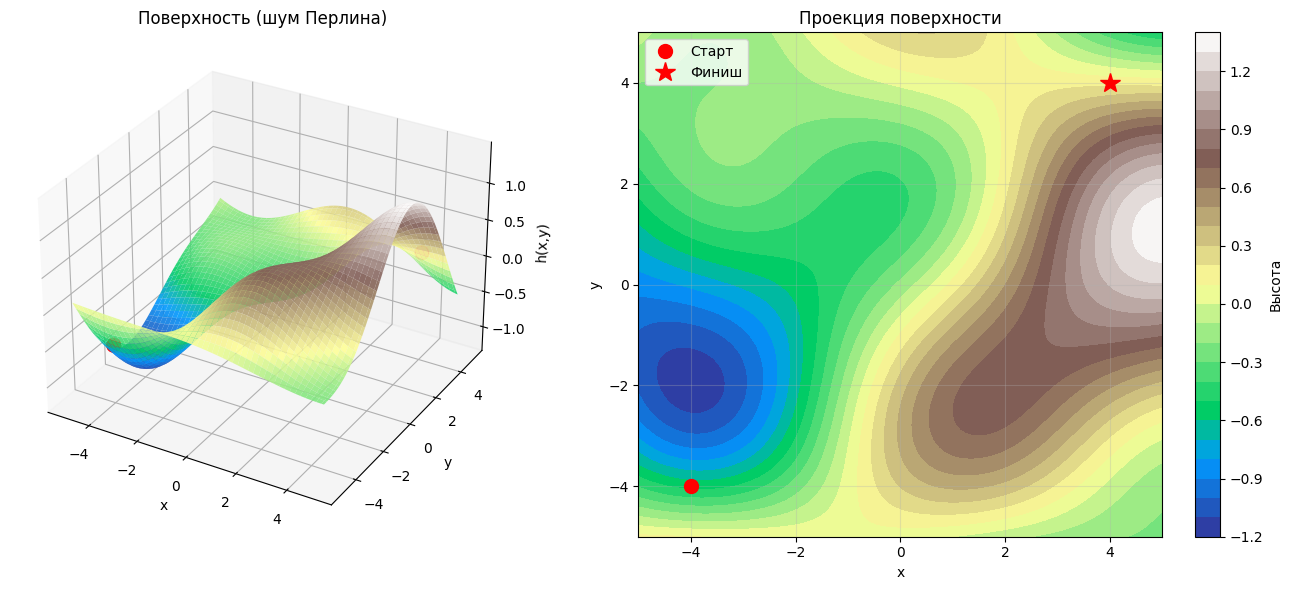

In [28]:
# --- Параметры области и сетки ---
x_min, x_max = -5.0, 5.0
y_min, y_max = -5.0, 5.0
nx, ny = 100, 100  # разрешение сетки поверхности

x_surf = np.linspace(x_min, x_max, nx)
y_surf = np.linspace(y_min, y_max, ny)
X_surf, Y_surf = np.meshgrid(x_surf, y_surf)

# --- Ваши параметры варианта (заполните!) ---
params_variant = params # Используем общие параметры варианта      # ваш сид
    

# --- Генерация поверхности ---
H_surf, dHdx_surf, dHdy_surf = generate_perlin_surface(X_surf, Y_surf, params_variant)

# --- Визуализация поверхности ---
fig = plt.figure(figsize=(14, 6))

# 3D-график
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_surf, Y_surf, H_surf, cmap='terrain', alpha=0.9, linewidth=0)
ax1.scatter([params_variant['x_start'], params_variant['x_end']], 
            [params_variant['y_start'], params_variant['y_end']], 
            [generate_perlin_surface(params_variant['x_start'], params_variant['y_start'], params_variant)[0], generate_perlin_surface(params_variant['x_end'], params_variant['y_end'], params_variant)[0]], 
            color='red', s=100, zorder=5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('h(x,y)')
ax1.set_title('Поверхность (шум Перлина)')

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_surf, Y_surf, H_surf, levels=30, cmap='terrain')
plt.colorbar(contour, ax=ax2, label='Высота')
ax2.plot(params_variant['x_start'], params_variant['y_start'], 'ro', markersize=10, label='Старт')
ax2.plot(params_variant['x_end'], params_variant['y_end'], 'r*', markersize=15, label='Финиш')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Проекция поверхности')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 4.4. Дискретизация траектории и вычисление функционала

 Задание: 
1. Создайте массив узлов траектории `x_traj` на отрезке `[x_start, x_end]` с `N_nodes` точками.
2. Реализуйте функцию `compute_functional(y_inner, x_traj, h_func, grad_h_func, params)`, вычисляющую значение дискретного функционала $\Phi$.
3. Реализуйте функцию `compute_gradient(y_inner, x_traj, h_func, grad_h_func, params)`, вычисляющую градиент $\nabla \Phi$ по внутренним узлам $y_1, \ldots, y_{N-1}$.

>  Важно:  Функции `h_func` и `grad_h_func` должны принимать скалярные координаты `(x, y)` и возвращать значение высоты и градиент в этой точке. Для интерполяции значений с сетки `H_surf` используйте `scipy.interpolate.RegularGridInterpolator` или `np.interp`.



In [29]:
from scipy.interpolate import RegularGridInterpolator

# --- Подготовка интерполяторов для поверхности и её градиента ---
# ===== ВАШ КОД ЗДЕСЬ =====
# Создайте interpolator_h, interpolator_dhdx, interpolator_dhdy
# Пример: interpolator_h = RegularGridInterpolator((y_surf, x_surf), H_surf, method='linear')

interpolator_h = RegularGridInterpolator((y_surf, x_surf), H_surf, method='linear', bounds_error=False, fill_value=None)
interpolator_dhdx = RegularGridInterpolator((y_surf, x_surf), dHdx_surf, method='linear', bounds_error=False, fill_value=None)
interpolator_dhdy = RegularGridInterpolator((y_surf, x_surf), dHdy_surf, method='linear', bounds_error=False, fill_value=None)
def h_interp(x, y):
    """Интерполяция высоты в точке (x, y)."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    return interpolator_h((y, x))

def grad_h_interp(x, y):
    """Интерполяция градиента поверхности в точке (x, y). Возвращает (dh/dx, dh/dy)."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    return interpolator_dhdx((y, x)), interpolator_dhdy((y, x))


In [30]:
def compute_functional(y_inner, x_traj, h_func, grad_h_func, params):
    """
    Вычисление дискретного функционала Φ.
    
    Параметры:
        y_inner: массив внутренних узлов траектории [y_1, ..., y_{N-1}]
        x_traj: массив всех узлов по x (включая граничные)
        h_func, grad_h_func: функции для вычисления высоты и градиента
        params: словарь параметров (A_weight, B_weight, ...)
    
    Возвращает:
        phi: значение функционала
    """
    A = params['A_weight']
    B = params['B_weight']
    N = len(x_traj) - 1
    dx = x_traj[1] - x_traj[0]
    
    # Собираем полный вектор y: [y_start, y_inner, y_end]
    y_full = np.concatenate(([params['y_start']], y_inner, [params['y_end']]))
    
    phi = 0.0
    for i in range(N):
        # ===== ВАШ КОД ЗДЕСЬ =====
        dy_dx = (y_full[i+1] - y_full[i]) / dx
        arc_length_element = np.sqrt(1 + dy_dx**2) * dx
        dhdx, dhdy = grad_h_func(x_traj[i], y_full[i])
        grad_norm = np.sqrt(dhdx**2 + dhdy**2)
        phi += (A + B * grad_norm) * arc_length_element
    
    return phi


def compute_gradient(y_inner, x_traj, h_func, grad_h_func, params):
    """
    Вычисление градиента функционала по внутренним узлам.
    
    Возвращает:
        grad: массив длины N-1 с частными производными dΦ/dy_j
    """
    A = params['A_weight']
    B = params['B_weight']
    N = len(x_traj) - 1
    dx = x_traj[1] - x_traj[0]
    y_full = np.concatenate(([params['y_start']], y_inner, [params['y_end']]))
    
    grad = np.zeros(len(y_inner))
    
    for j in range(1, N):  # j соответствует индексу внутреннего узла
        # ===== ВАШ КОД ЗДЕСЬ =====
        eps = 1e-6
        def local_phi(yj_val):
            p = 0.0
            for i in [j-1, j]:
                if i < 0 or i >= N: continue
                y_curr = yj_val if i == j-1 else y_full[i]
                y_next = yj_val if i == j else y_full[i+1]
                dy_dx = (y_next - y_curr) / dx
                dl = np.sqrt(1 + dy_dx**2) * dx
                gx, gy = grad_h_func(x_traj[i], y_curr)
                gn = np.sqrt(gx**2 + gy**2)
                p += (A + B * gn) * dl
            return p
        grad[j-1] = (local_phi(y_full[j] + eps) - local_phi(y_full[j] - eps)) / (2 * eps)
    
    return grad


In [31]:
# --- Проверка градиента численным дифференцированием (опционально, но рекомендуется) ---
y_test = np.linspace(params_variant['y_start'], params_variant['y_end'], params_variant['N_nodes'] + 1)[1:-1]
grad_analytic = compute_gradient(y_test, 
                                  np.linspace(params_variant['x_start'], params_variant['x_end'], params_variant['N_nodes'] + 1),
                                  h_interp, grad_h_interp, params_variant)

eps = 1e-6
grad_numeric = np.zeros_like(y_test)
for k in range(len(y_test)):
    y_plus = y_test.copy()
    y_minus = y_test.copy()
    y_plus[k] += eps
    y_minus[k] -= eps
    grad_numeric[k] = (compute_functional(y_plus, 
                                          np.linspace(params_variant['x_start'], params_variant['x_end'], params_variant['N_nodes'] + 1),
                                          h_interp, grad_h_interp, params_variant) -
                       compute_functional(y_minus, 
                                          np.linspace(params_variant['x_start'], params_variant['x_end'], params_variant['N_nodes'] + 1),
                                          h_interp, grad_h_interp, params_variant)) / (2 * eps)

print(f"Проверка градиента (макс. отклонение): {np.max(np.abs(grad_analytic - grad_numeric)):.2e}")


Проверка градиента (макс. отклонение): 5.84e-02



## 4.5. Численная оптимизация траектории

 Задание: 
1. Используя метод градиентного спуска , найдите оптимальную траекторию, минимизирующую функционал $\Phi$.
2. Сохраняйте значения функционала и траектории на каждой итерации для последующей визуализации процесса сходимости.
3. Подберите шаг обучения $\gamma$ экспериментально (начните с $\gamma = 0.01$).



In [32]:
# --- Подготовка данных для оптимизации ---
x_traj = np.linspace(params_variant['x_start'], params_variant['x_end'], params_variant['N_nodes'] + 1)
y_init = np.linspace(params_variant['y_start'], params_variant['y_end'], params_variant['N_nodes'] + 1)[1:-1]  # начальное приближение — прямая

gamma_opt = 0.05 / params_variant['N_nodes']
max_iter_opt = 2000
tol_opt = 1e-8

# --- Градиентный спуск ---
y_current = y_init.copy()
Phi_history = []
trajectory_history = []  # для визуализации промежуточных итераций

for k in range(max_iter_opt):
    phi_val = compute_functional(y_current, x_traj, h_interp, grad_h_interp, params_variant)
    Phi_history.append(phi_val)
    trajectory_history.append(y_current.copy())
    
    grad_val = compute_gradient(y_current, x_traj, h_interp, grad_h_interp, params_variant)
    
    if np.linalg.norm(grad_val) < tol_opt:
        print(f"Сходимость достигнута за {k} итераций")
        break
    
    # ===== ВАШ КОД ЗДЕСЬ (шаг градиентного спуска) =====
    y_current = y_current - gamma_opt * grad_val
    


y_optimal = np.concatenate(([params_variant['y_start']], y_current, [params_variant['y_end']]))
print(f"Оптимальное значение функционала: Φ = {Phi_history[-1]:.6f}")


Оптимальное значение функционала: Φ = 15.496418


In [33]:
# --- Альтернатива: использование scipy.optimize.minimize ---
# from scipy.optimize import minimize
# 
# result = minimize(lambda y: compute_functional(y, x_traj, h_interp, grad_h_interp, params_variant),
#                   x0=y_init,
#                   method='BFGS',
#                   jac=lambda y: compute_gradient(y, x_traj, h_interp, grad_h_interp, params_variant),
#                   options={'maxiter': max_iter_opt, 'gtol': tol_opt})
# 
# y_optimal = np.concatenate(([params_variant['y_start']], result.x, [params_variant['y_end']]))
# print(f"scipy.optimize: Φ = {result.fun:.6f}, итераций: {result.nit}")



## 4.6. Визуализация и интерпретация результатов

 Задание: 
1. Постройте финальную визуализацию: 3D-график поверхности с нанесённой оптимальной траекторией и 2D-контурный график с проекцией пути.
2. Создайте анимацию или серию кадров, показывающих эволюцию траектории в процессе оптимизации (используйте `trajectory_history`).
3. Постройте график сходимости: значение функционала $\Phi$ от номера итерации.
4. Ответьте на вопросы для интерпретации.



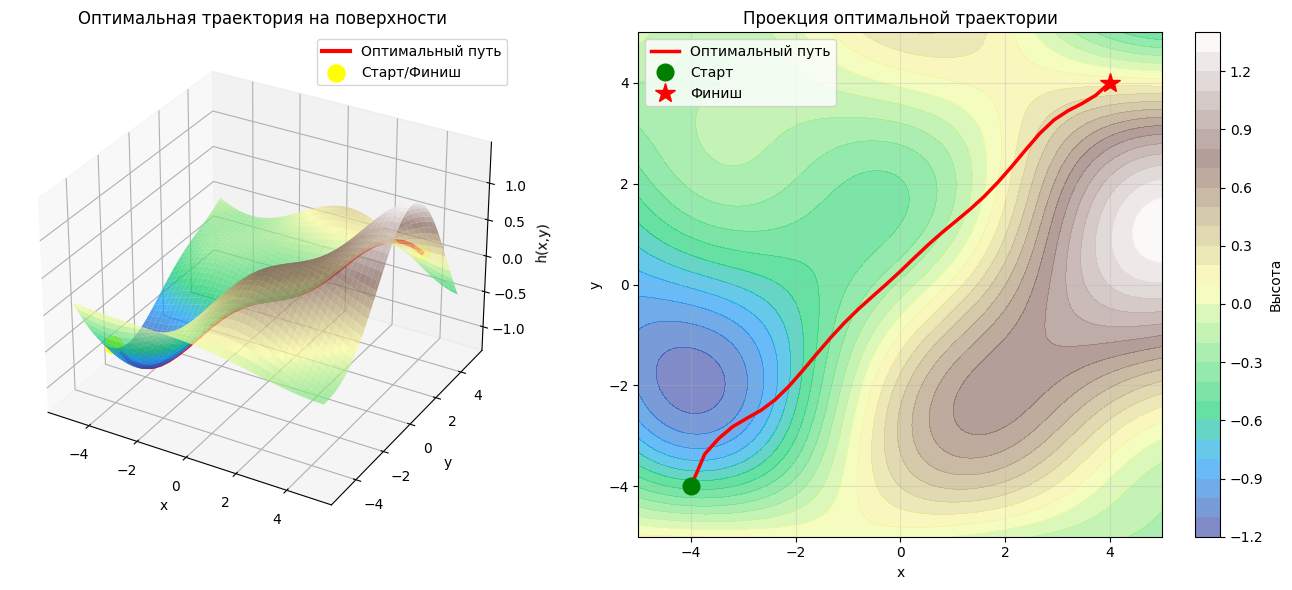

In [34]:
# --- Финальная визуализация: 3D и 2D ---
fig = plt.figure(figsize=(14, 6))

# 3D-график с траекторией
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_surf, Y_surf, H_surf, cmap='terrain', alpha=0.7, linewidth=0)
# Вычислим высоты вдоль траектории для 3D-отображения
z_traj = np.array([h_interp(x, y) for x, y in zip(x_traj, y_optimal)])
ax1.plot(x_traj, y_optimal, z_traj, 'r-', linewidth=3, label='Оптимальный путь')
ax1.scatter([x_traj[0], x_traj[-1]], [y_optimal[0], y_optimal[-1]], [z_traj[0], z_traj[-1]], 
            color='yellow', s=150, zorder=5, label='Старт/Финиш')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('h(x,y)')
ax1.set_title('Оптимальная траектория на поверхности')
ax1.legend()

# 2D-контурный график с проекцией пути
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_surf, Y_surf, H_surf, levels=30, cmap='terrain', alpha=0.6)
plt.colorbar(contour, ax=ax2, label='Высота')
ax2.plot(x_traj, y_optimal, 'r-', linewidth=2.5, label='Оптимальный путь')
ax2.plot(x_traj[0], y_optimal[0], 'go', markersize=12, label='Старт')
ax2.plot(x_traj[-1], y_optimal[-1], 'r*', markersize=15, label='Финиш')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Проекция оптимальной траектории')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


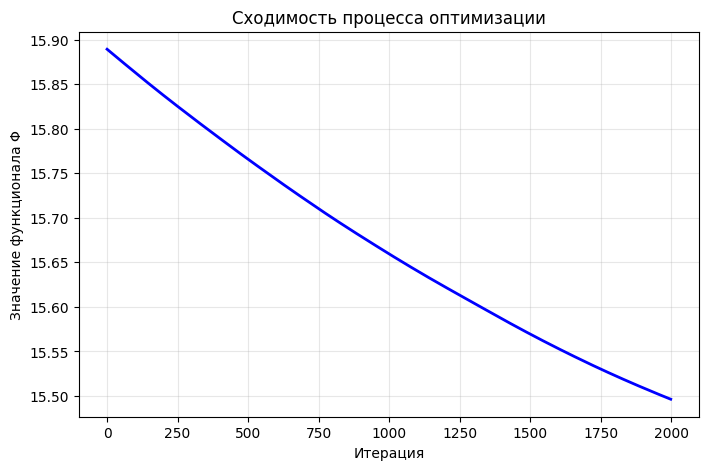

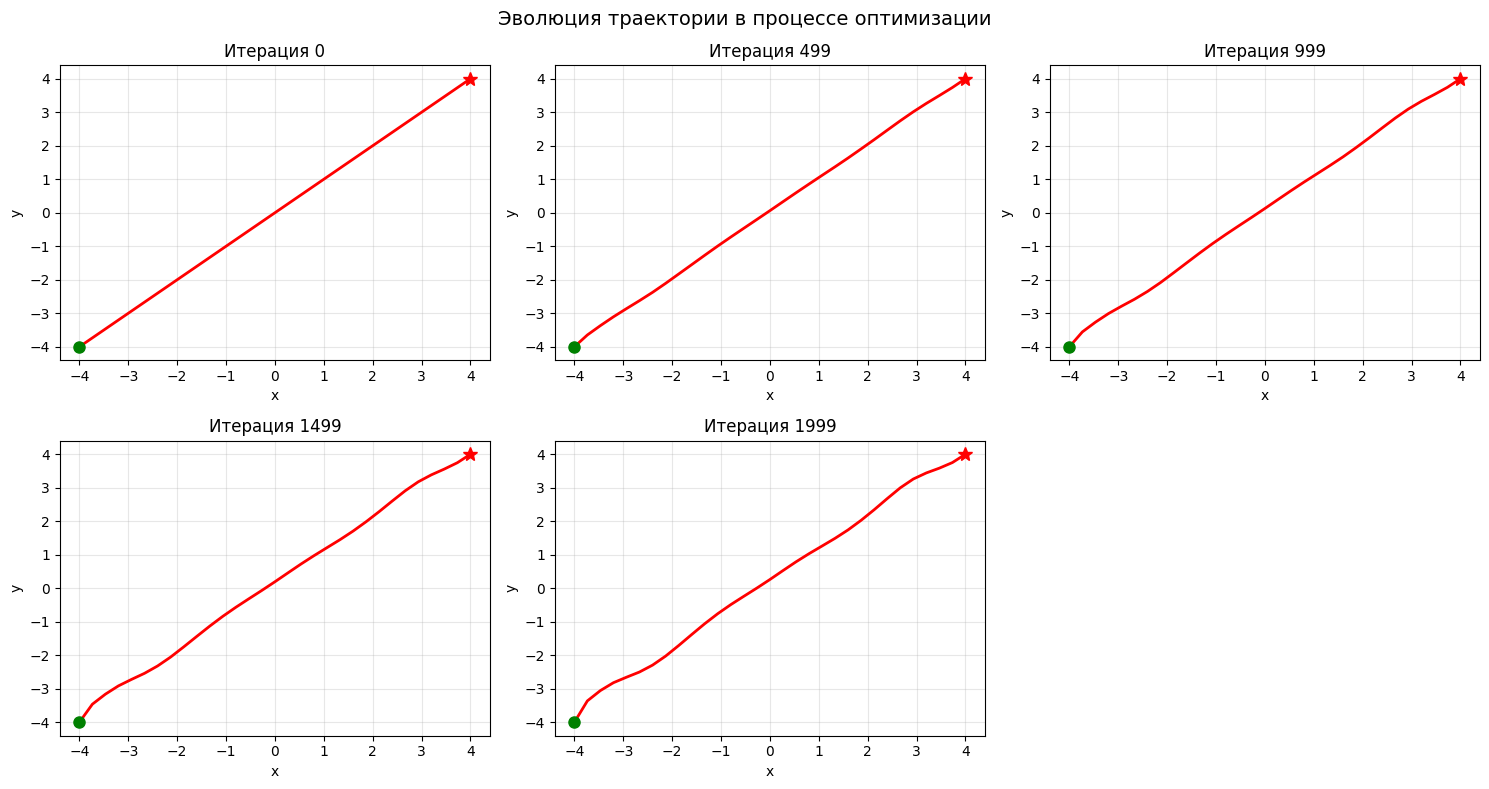

In [35]:
# --- График сходимости функционала ---
plt.figure(figsize=(8, 5))
plt.plot(Phi_history, 'b-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('Значение функционала Φ')
plt.title('Сходимость процесса оптимизации')
plt.grid(True, alpha=0.3)
plt.show()

# --- Визуализация промежуточных итераций (пример для 5 кадров) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
iter_indices = np.linspace(0, len(trajectory_history)-1, 5, dtype=int)

for idx, ax in zip(iter_indices, axes):
    y_curr = np.concatenate(([params_variant['y_start']], trajectory_history[idx], [params_variant['y_end']]))
    z_curr = np.array([h_interp(x, y) for x, y in zip(x_traj, y_curr)])
    
    ax.plot(x_traj, y_curr, 'r-', linewidth=2)
    ax.plot(x_traj[0], y_curr[0], 'go', markersize=8)
    ax.plot(x_traj[-1], y_curr[-1], 'r*', markersize=10)
    ax.set_title(f'Итерация {idx}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')  # пустой подграфик
plt.suptitle('Эволюция траектории в процессе оптимизации', fontsize=14)
plt.tight_layout()
plt.show()



---
> ❗  Вопросы для интерпретации результатов  ❗
>
> 1.  **Физическая интерпретация:** Почему оптимальный путь имеет именно такую форму? Как на него повлияли коэффициенты $A$ и $B$? Что произошло бы, если бы $B$ было значительно больше?
> 2.  **Алгоритмическая часть:** Сколько итераций потребовалось для сходимости? Как выбор шага $\gamma$ влияет на скорость и устойчивость процесса? Почему использование аналитического градиента предпочтительнее численного?
> 3.  **Анализ чувствительности:** Как изменится траектория, если изменить параметры шума Перлина (частоту, число октав)? Проведите мысленный эксперимент: что будет, если начальная и конечная точки окажутся по разные стороны «горного хребта»?
> 4.  **Сравнение методов:** Попробуйте решить ту же задачу с помощью `scipy.optimize.minimize` (метод BFGS или L-BFGS-B). Сравните число итераций и итоговое значение функционала с вашим реализованным градиентным спуском.
>
> ***Ваши ответы:** 
>
>
---

## 4.7. Самостоятельное исследование (дополнительное задание)

 Задание для углублённого изучения: 
1. Модифицируйте функционал, добавив штраф за резкие изменения направления: $\mathcal{J}_{new} = \mathcal{J} + C \int (y''(x))^2 dx$. Реализуйте дискретизацию второго производного и соответствующий градиент.
2. Исследуйте, как параметр $C$ влияет на «плавность» оптимальной траектории.
3. Попробуйте использовать метод Ньютона для минимизации функционала. Для этого реализуйте вычисление (или аппроксимацию) матрицы Гессе дискретного функционала.
4. Сравните время работы и точность методов градиентного спуска и Ньютона для вашей задачи.



/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/3002970840.py:26: RuntimeWarning: overflow encountered in scalar power
  arc_length_element = np.sqrt(1 + dy_dx**2) * dx
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/3002970840.py:28: RuntimeWarning: overflow encountered in square
  grad_norm = np.sqrt(dhdx**2 + dhdy**2)
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/1142146177.py:25: RuntimeWarning: overflow encountered in scalar power
  curvature_penalty += (y_double_prime**2) * dx
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/3002970840.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  dy_dx = (y_full[i+1] - y_full[i]) / dx
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77762/1142146177.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  y_double_prime = (y_full[i+1] - 2*y_full[i] + y_full[i-1]) / dx**2
/var/folders/m6/zg0nj7_90zsbrjs7nrj33m9c0000gn/T/ipykernel_77

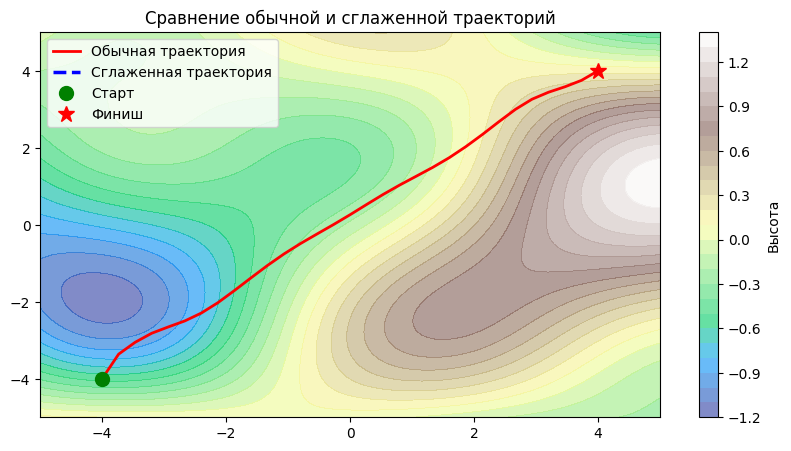

In [36]:
# ===== ШАБЛОН ДЛЯ ДОПОЛНИТЕЛЬНОГО ЗАДАНИЯ =====
# Раскомментируйте и доработайте при необходимости

def compute_functional_smooth(y_inner, x_traj, h_func, grad_h_func, params):
    """Функционал с дополнительным штрафом за кривизну."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    phi = compute_functional(y_inner, x_traj, h_func, grad_h_func, params)
    dx = x_traj[1] - x_traj[0]
    y_full = np.concatenate(([params['y_start']], y_inner, [params['y_end']]))
    curvature_penalty = 0.0
    for i in range(1, len(x_traj)-1):
        y_double_prime = (y_full[i+1] - 2*y_full[i] + y_full[i-1]) / dx**2
        curvature_penalty += (y_double_prime**2) * dx
    return phi + 1.0 * curvature_penalty

def compute_gradient_smooth(y_inner, x_traj, h_func, grad_h_func, params):
    """Градиент функционала с учётом штрафа за кривизну."""
    # ===== ВАШ КОД ЗДЕСЬ =====
    phi = compute_functional(y_inner, x_traj, h_func, grad_h_func, params)
    dx = x_traj[1] - x_traj[0]
    y_full = np.concatenate(([params['y_start']], y_inner, [params['y_end']]))
    curvature_penalty = 0.0
    for i in range(1, len(x_traj)-1):
        y_double_prime = (y_full[i+1] - 2*y_full[i] + y_full[i-1]) / dx**2
        curvature_penalty += (y_double_prime**2) * dx
    return phi + 1.0 * curvature_penalty

# --- Пример запуска с новым функционалом ---
# ...

# --- Выполнение дополнительного задания ---
y_smooth_current = y_init.copy()
gamma_smooth = 0.01 / params_variant['N_nodes']
for _ in range(500):
    g_smooth = compute_gradient_smooth(y_smooth_current, x_traj, h_interp, grad_h_interp, params_variant)
    if np.linalg.norm(g_smooth) < 1e-6: break
    y_smooth_current -= gamma_smooth * g_smooth
y_smooth_optimal = np.concatenate(([params_variant['y_start']], y_smooth_current, [params_variant['y_end']]))
plt.figure(figsize=(10, 5))
contour = plt.contourf(X_surf, Y_surf, H_surf, levels=30, cmap='terrain', alpha=0.6)
plt.colorbar(contour, label='Высота')
plt.plot(x_traj, y_optimal, 'r-', linewidth=2, label='Обычная траектория')
plt.plot(x_traj, y_smooth_optimal, 'b--', linewidth=2.5, label='Сглаженная траектория')
plt.plot(x_traj[0], y_optimal[0], 'go', markersize=10, label='Старт')
plt.plot(x_traj[-1], y_optimal[-1], 'r*', markersize=12, label='Финиш')
plt.legend()
plt.title('Сравнение обычной и сглаженной траекторий')
plt.show()



---
> ❗  Итоговый вопрос  ❗
>
>  Как данная лабораторная работа иллюстрирует связь между:
>  - вариационным исчислением (непрерывная постановка),
>  - дискретизацией (переход к конечномерной задаче),
>  - численными методами оптимизации (градиентный спуск, метод Ньютона),
>  - прикладной инженерной задачей (планирование траектории робота)?
>
>  Опишите, какие этапы решения были наиболее сложными и почему.
>
> ***Ваш ответ:** 
>
>
---
